# Run infection dynamics with monoclonal killer T cell response

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
# %config InlineBackend.figure_format = 'retina'
%load_ext line_profiler

In [4]:
len(psi_opts)/100

585.64

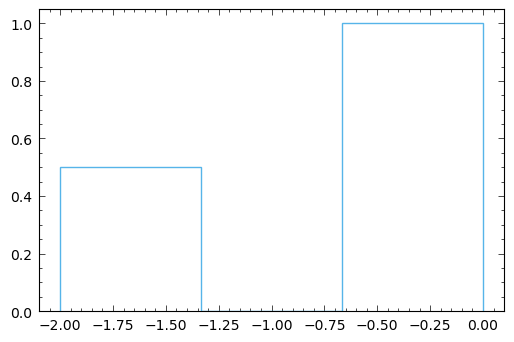

In [3]:
#plt.hist(np.argmax(mycNa > 0, axis = 0)*sim_duration/sim_steps, bins='auto')
# plt.hist(psi_opts[:,0], bins='auto', histtype='step');
plt.hist(psi_2d[1], bins='auto', density = True, histtype='step');
#plt.hist(psi_opts[:,2], bins='auto', histtype='step');

### (1) Plot population averaged trajectories

In [4]:
# Set simulation parameters
N_0 = 100
K_IE = (1)*(10**4)
d_I = 1*d_S
infection_type = "prim" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"
reg = psi_max*np.array([-0.5, -0.5, -0.0, -0.5, -0.5, -0.0])

In [5]:
# %lprun -T lprof0 -f lin_stoch_sim lin_stoch_sim(N_0 = 100)

In [6]:
# Run single simulation
# %timeit -n 2 -r 2
data_dict = lin_stoch_sim(N_0 = N_0, b_I = b_I, 
                          K_IE = K_IE,
                          d_I = d_I,
                          K_IH = K_IH,
                          memory_regulation = reg,
                          infection = infection_type,
                          vir_model = "dep_harm",
                          out_data = "full")

In [7]:
regs = data_dict["reg_coeffs"]
dyn = data_dict["cell_time_series"]
ts = data_dict["time"]
lin_comp = data_dict["lineage_diff"]
p_diff = data_dict["prim_diff_bias"]
s_diff = data_dict["sec_diff_bias"]
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
mycNa = data_dict["Na_myc_by_lin"]
mycMa = data_dict["Ma_myc_by_lin"]
mycE = data_dict["E_myc_by_lin"]
Eff = data_dict["eff_by_lin"]
T_pEcytM = data_dict["pmemory_formed"]
T_sEcytM = data_dict["pmemory_survived"]

S, I, A, Na, E, M, H, I_d_I, I_d_S = dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

reg_string = '-'.join((reg * 1).astype('U1'))

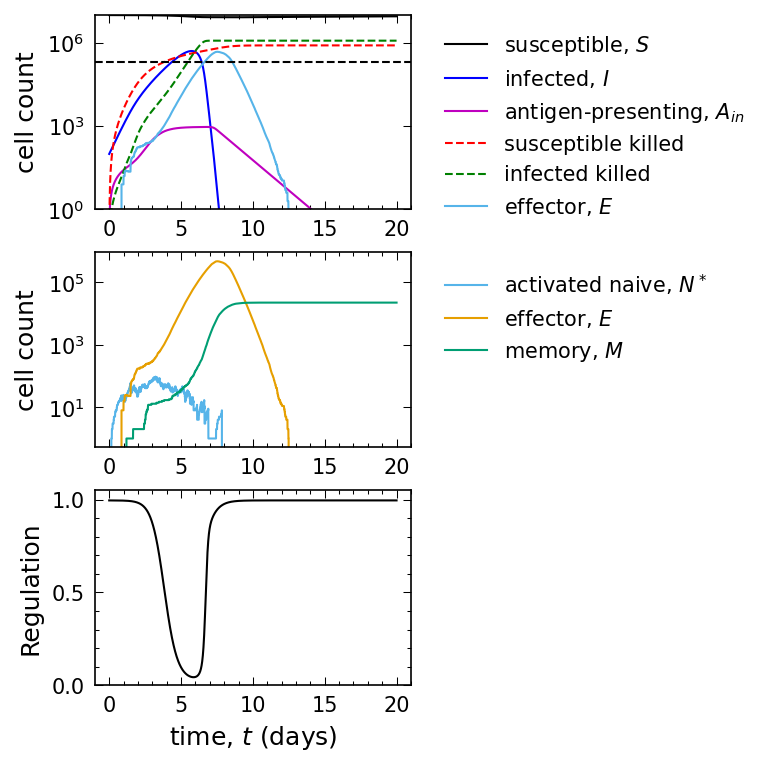

In [8]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_S, 'r', linestyle = '--', label = r'susceptible killed')
ax1.plot(ts, I_d_I, 'g', linestyle = '--', label = r'infected killed')
ax1.plot(ts, E, label = r'effector, $E$')
ax1.axhline(y = d_S/b_I, color = 'k', linestyle = '--')
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, label = r'activated naive, $N^*$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, M, label = r'memory, $M$')
ax2.set(ylabel='cell count')
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, f_XtoY(I, H, psi_I = reg[0], psi_H = reg[1], psi_IH = reg[2]/2, F_0 = -np.sum(reg), K_I = K_EI, K_H = K_EH),
         'k-', label = r'Regulation, $f(I,H)$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='Regulation')
ax3.set_ylim(0,1.05)

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

/var/folders/_q/50__mrnj2zv6hb8crhk3q46m0000gn/T/ipykernel_35305/1408007461.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(ts, np.log(H/K_IH), 'k--')


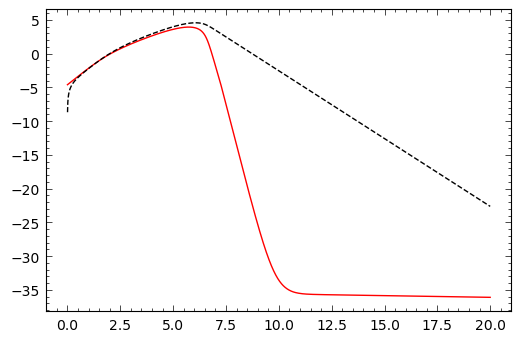

In [9]:
plt.plot(ts, np.log(I/K_IE), 'r')
plt.plot(ts, np.log(H/K_IH), 'k--')

In [10]:
print(f'Memory fraction = {(np.max(M))/np.max(E)}')
print(f'Number of memory cells = {np.max(M)}')
print(f'1st infection harm = {sim_summary[4]/(d_S*S_0)}')
print(f'2nd infection harm = {sim_summary[5]/(d_S*S_0)}')
print(f'1st response harm = {sim_summary[6]/(d_S*S_0)}')
print(f'2nd response harm = {sim_summary[7]/(d_S*S_0)}')
print(f'Minimum susceptible = {np.min(S)/S_0}')

Memory fraction = 0.047258363536151524
Number of memory cells = 22636.0
1st infection harm = 2.398973861118646
2nd infection harm = 2.398973861118646
1st response harm = 1.6209173403565373
2nd response harm = 1.6209173403565373
Minimum susceptible = 0.8342893114387264


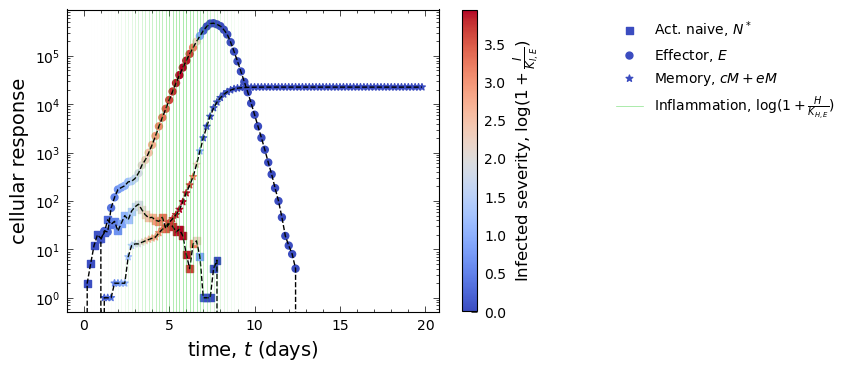

In [11]:
# Plot simulated infection dynamics: pretty plots
pnts = 100
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = Na[keep]
eff = E[keep]
mem = M[keep]
p_load = np.log(1 + I[keep]/K_IE)
inflam = np.log(1 + H[keep]/K_EH)/8
time = ts[keep]

plt.scatter(time, naive, marker ='s', c = p_load, cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
plt.plot(time, naive, 'k--')
plt.scatter(time, eff, marker ='o', c = p_load, cmap='coolwarm', 
            label = r'Effector, $E$') #, norm=mpl.colors.LogNorm())
plt.plot(time, eff, 'k--')
plt.scatter(time, mem, marker ='*', c = p_load, cmap='coolwarm',
            label = r'Memory, $cM+eM$') #, norm=mpl.colors.LogNorm())
plt.plot(time, mem, 'k--')

plt.colorbar(label =r"Infected severity, $\log(1 + \frac{I}{K_{I,E}})$")
plt.ylabel('cellular response', fontsize = 14)
plt.xlabel(r"time, $t$ (days)", fontsize = 14)
plt.semilogy()

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $\log(1 + \frac{H}{K_{H,E}})$")
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])

plt.legend(loc='center right', bbox_to_anchor=(2.1, 0.8), fontsize = 10)

plt.savefig('_figs/'+infection_type+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

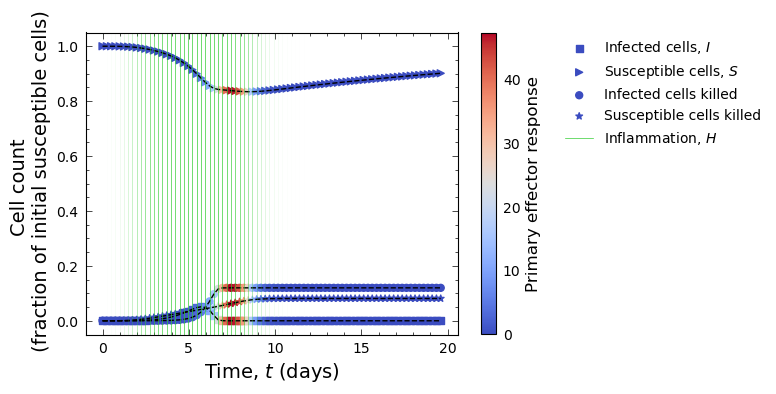

In [12]:
# Plot simulated infection dynamics: pretty plots of harm
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]

eff = E[keep]
p_load = I[keep]/S_0
sus = S[keep]/S_0
inf_harm = I_d_I[keep]/S_0
inflam_harm = I_d_S[keep]/S_0
inflam = H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

plt.scatter(time, p_load, marker ='s', c =eff/K_IE, cmap='coolwarm', 
            label = r'Infected cells, $I$') #, norm=mpl.colors.LogNorm())
plt.plot(time, p_load, 'k--')

plt.scatter(time, sus, marker ='>', c =eff/K_IE, cmap='coolwarm', 
            label = r'Susceptible cells, $S$') #, norm=mpl.colors.LogNorm())
plt.plot(time, sus, 'k--')

plt.scatter(time, inf_harm, marker ='o', c =eff/K_IE, cmap='coolwarm', 
            label = 'Infected cells killed')
plt.plot(time, inf_harm, 'k--')

plt.scatter(time, inflam_harm, marker ='*', c =eff/K_IE, cmap='coolwarm',
            label = 'Susceptible cells killed')
plt.plot(time, inflam_harm, 'k--')

plt.colorbar(label = "Primary effector response")
plt.ylabel('Cell count \n (fraction of initial susceptible cells)', fontsize = 14)
plt.xlabel(r"Time, $t$ (days)", fontsize = 14)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])
        
plt.legend(loc='center right', bbox_to_anchor=(1.85, 0.8), fontsize = 10)
plt.savefig('_figs/'+infection_type+'-infection-harm-'+reg_string+'.png', dpi=300, bbox_inches="tight")

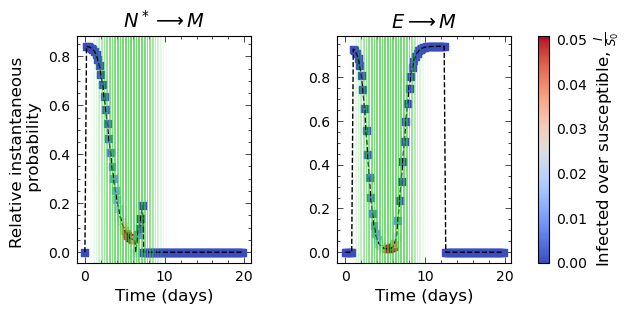

In [13]:
# Plot simulated infection dynamics: pretty plots
pnts = 100
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
bias_diff = p_diff[keep] if infection_type == "prim" else s_diff[keep]
p_load = I[keep]
sus = S[keep]
inflam =  H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

fig, axs = plt.subplots(1,2, figsize=(7,3))

if infection_type == "prim":
    im1 = axs[0].scatter(time, bias_diff[:,0], marker = 's', c =p_load/S_0, cmap='coolwarm', 
                label = r'$N^* \longrightarrow M$')
    axs[0].plot(time, bias_diff[:,0],'k--')
    axs[0].title.set_text(r'$N^* \longrightarrow M$')

elif infection_type == "sec":
    im1 = axs[0].scatter(time, bias_diff[:,2], marker = 'o', c =p_load/sus, cmap='coolwarm', 
                label = r'$M$')
    axs[0].plot(time, bias_diff[:,2],'k--')
    axs[0].title.set_text(r'$pM \longrightarrow sM$')

im3 = axs[1].scatter(time, bias_diff[:,1], marker = 's', c =p_load/sus, cmap='coolwarm', 
            label = r'$E \longrightarrow M$')
axs[1].plot(time, bias_diff[:,1],'k--')
axs[1].title.set_text(r'$E \longrightarrow M$')

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        axs[0].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
        axs[1].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        axs[0].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])
        axs[1].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")


axs[0].set(ylabel='Relative instantaneous \n probability', 
           xlabel="Time (days)")
axs[1].set(ylabel='', 
           xlabel="Time (days)")

fig.subplots_adjust(wspace=.5)
cb = fig.colorbar(im1, ax=axs, orientation='vertical')
cb.set_label(r"Infected over susceptible, $\frac{I}{S_0}$")

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_type+'-diff-bias-over-time-'+reg_string+'.png', dpi=300, bbox_inches="tight")

### (2) Plot lineage-based trajectories

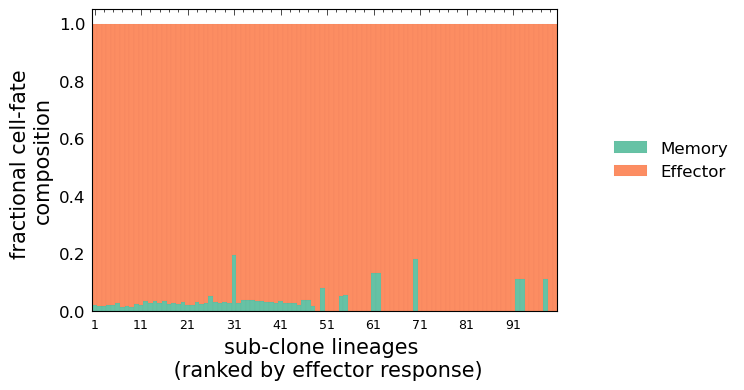

In [14]:
keys = np.array(['Memory', 'Effector'])
all_counts = lin_comp[1:3].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.01,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)))
ax.set_xticklabels(1 + np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)), fontsize=9)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_type+'-'+'fates-by-lin-'+reg_string+'.png', dpi=300, bbox_inches="tight")


[]

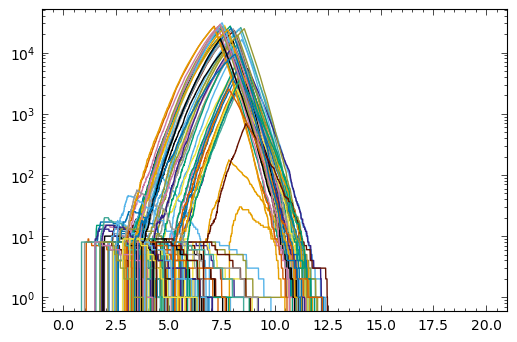

In [15]:
plt.plot(ts, Eff)
plt.semilogy()

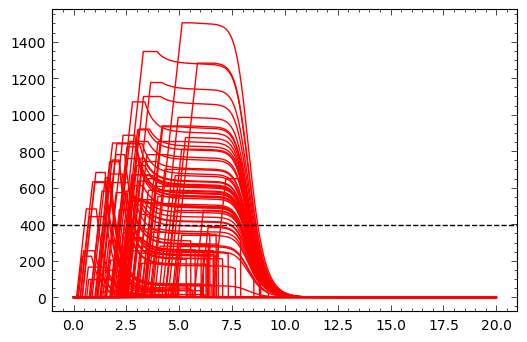

In [16]:
plt.plot(ts, mycE, 'r-')
#plt.plot(ts, mycMa, 'k-')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
#plt.semilogy()

In [17]:
np.sum(np.max(mycE, axis=0) < myc_thresh)/N_0

0.33

0.0


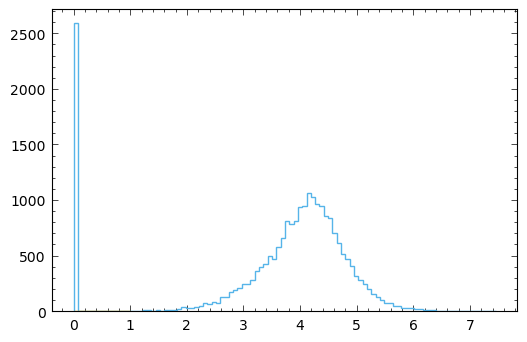

In [18]:
#plt.hist(np.argmax(mycNa > 0, axis = 0)*sim_duration/sim_steps, bins='auto')
plt.hist(T_pEcytM, bins='auto', histtype='step');
plt.hist(T_sEcytM, bins='auto', histtype='step');
print(len(T_sEcytM)/len(T_pEcytM))

Text(0.5, 0.98, 'Peak response response: $N_0=$ 100, $d_I=$0.05')

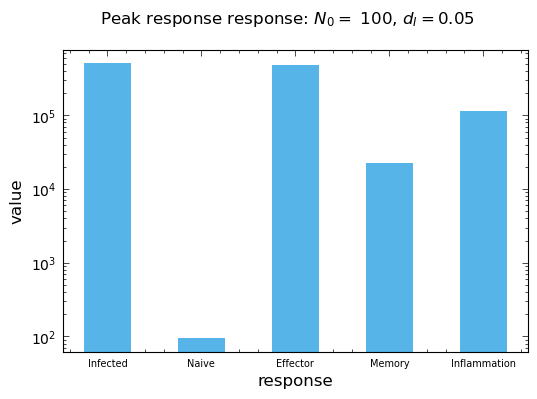

In [19]:
# Compute max values in the data
r = np.arange(5)
width = 0.5
plt.bar(r, np.amax(np.array([I, Na, E, M, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Memory", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

/var/folders/_q/50__mrnj2zv6hb8crhk3q46m0000gn/T/ipykernel_35305/2593391488.py:11: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(ts, A/(Na + A))


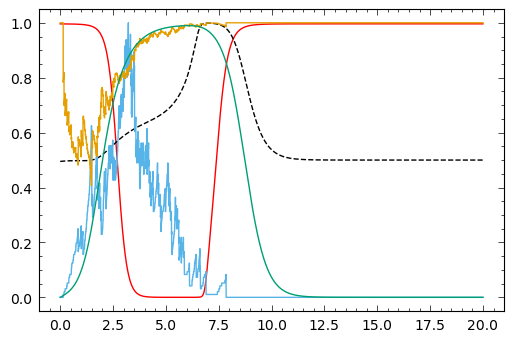

In [20]:
bias_1 = f_XtoY(I, H, 
       -2.0, -2.0, 0.0, F_0 = 4*np.log(2), 
       K_I = K_IE, K_H = K_EH)
bias_2 = f_XtoY(I, H, 
       -2.0, 2.0, 0.0, F_0 = -0*np.log(2), 
       K_I = K_IE, K_H = K_EH)

plt.plot(ts, bias_1, 'r')
plt.plot(ts, bias_2, 'k--')
plt.plot(ts, Na/np.amax(Na))
plt.plot(ts, A/(Na + A))
plt.plot(ts, H**l_H/(K_EH**l_H + H**l_H))

In [21]:
# runs = 1
# vir_samp = np.tile(vir_prop, (runs,1))
# d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/"

# run(batch = [0], outdir=d, virus_sample = vir_samp, comment="lin-based")